In [1]:
# Import all libraries required for data analysis, preprocessing, model building and evaluation.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
data = pd.read_csv("8_src\loan_data.csv")
print("Dataset loaded successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '8_src\\loan_data.csv'

In [ ]:
# Display the first five rows to understand the structure of the dataset.

data.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [ ]:
# Check the number of rows and columns in the dataset.

print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

Rows: 45000
Columns: 14


In [ ]:
# Display all feature and target column names.

print(data.columns.tolist())

['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status']


In [ ]:
# Check data types and non-null values for every column.

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [ ]:
# Check whether any column contains missing values.

print(data.isnull().sum())

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


In [ ]:
# Check how many duplicate records exist in the dataset.

print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


In [ ]:
# Remove duplicate records so the same observation is not used multiple times.

data = data.drop_duplicates()

print("Shape after removing duplicates:", data.shape)

Shape after removing duplicates: (45000, 14)


In [ ]:
# Generate statistical information for numerical columns.

data.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [ ]:
# Check how many approved and rejected loans are present in the dataset.

print(data["loan_status"].value_counts())

loan_status
0    35000
1    10000
Name: count, dtype: int64


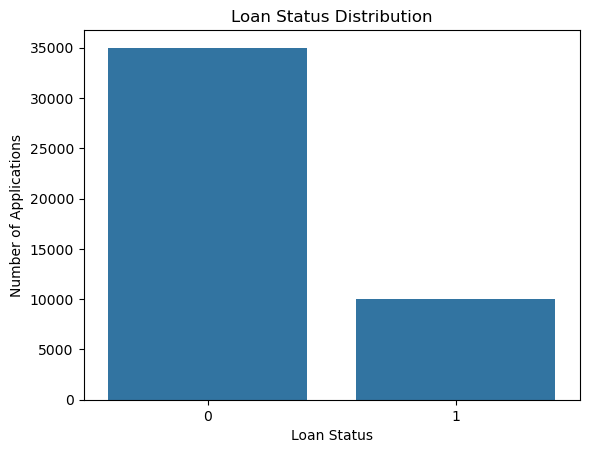

In [ ]:
# Visualize the number of approved and rejected loans.

sns.countplot(x="loan_status", data=data)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")

plt.show()

In [ ]:
# Separate the input features from the loan approval target variable.

X = data.drop("loan_status", axis=1)
y = data["loan_status"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (45000, 13)
Target shape: (45000,)


In [ ]:
# Define the columns containing categorical/text values that need encoding.

categorical_cols = [
    "person_gender",
    "person_education",
    "person_home_ownership",
    "loan_intent",
    "previous_loan_defaults_on_file"
]

print(categorical_cols)

['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']


In [ ]:
# Create and store one LabelEncoder for each categorical feature so Streamlit can reuse the same mappings.

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

print("Categorical encoding completed.")

Categorical encoding completed.


In [ ]:
# Display the original category-to-number mappings used by the model.

for col, le in encoders.items():
    print(f"\n{col}")
    print(dict(zip(le.classes_, le.transform(le.classes_))))


person_gender
{'female': np.int64(0), 'male': np.int64(1)}

person_education
{'Associate': np.int64(0), 'Bachelor': np.int64(1), 'Doctorate': np.int64(2), 'High School': np.int64(3), 'Master': np.int64(4)}

person_home_ownership
{'MORTGAGE': np.int64(0), 'OTHER': np.int64(1), 'OWN': np.int64(2), 'RENT': np.int64(3)}

loan_intent
{'DEBTCONSOLIDATION': np.int64(0), 'EDUCATION': np.int64(1), 'HOMEIMPROVEMENT': np.int64(2), 'MEDICAL': np.int64(3), 'PERSONAL': np.int64(4), 'VENTURE': np.int64(5)}

previous_loan_defaults_on_file
{'No': np.int64(0), 'Yes': np.int64(1)}


In [ ]:
# Verify that categorical text values have been converted into numerical values.

X.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
0,22.0,0,4,71948.0,0,3,35000.0,4,16.02,0.49,3.0,561,0
1,21.0,0,3,12282.0,0,2,1000.0,1,11.14,0.08,2.0,504,1
2,25.0,0,3,12438.0,3,0,5500.0,3,12.87,0.44,3.0,635,0
3,23.0,0,1,79753.0,0,3,35000.0,3,15.23,0.44,2.0,675,0
4,24.0,1,4,66135.0,1,3,35000.0,3,14.27,0.53,4.0,586,0


In [ ]:
# Split the dataset into training and testing data while preserving the target class distribution.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (36000, 13)
Testing data: (9000, 13)


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9261111111111111
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7000
           1       0.89      0.76      0.82      2000

    accuracy                           0.93      9000
   macro avg       0.91      0.87      0.89      9000
weighted avg       0.92      0.93      0.92      9000



In [ ]:
# Scale numerical features because KNN and Logistic Regression perform better when features are on comparable scales.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Find actual approved loans
approved = data[data["loan_status"] == 1]

print(approved.head(5))

   person_age person_gender person_education  person_income  person_emp_exp  \
0        22.0        female           Master        71948.0               0   
2        25.0        female      High School        12438.0               3   
3        23.0        female         Bachelor        79753.0               0   
4        24.0          male           Master        66135.0               1   
5        21.0        female      High School        12951.0               0   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   
2              MORTGAGE     5500.0     MEDICAL          12.87   
3                  RENT    35000.0     MEDICAL          15.23   
4                  RENT    35000.0     MEDICAL          14.27   
5                   OWN     2500.0     VENTURE           7.14   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.49                         3.0           561  

In [ ]:
# Train a Logistic Regression model as a baseline classification model.

log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
# Generate loan approval predictions using Logistic Regression.

y_pred_log = log_model.predict(X_test_scaled)

In [ ]:
# Evaluate the Logistic Regression model using accuracy and classification metrics.

print(
    "Logistic Regression Accuracy:",
    accuracy_score(y_test, y_pred_log)
)

print(
    classification_report(y_test, y_pred_log)
)

Logistic Regression Accuracy: 0.8967777777777778
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      7000
           1       0.78      0.75      0.76      2000

    accuracy                           0.90      9000
   macro avg       0.85      0.84      0.85      9000
weighted avg       0.90      0.90      0.90      9000



In [ ]:
# Train a K-Nearest Neighbors model using the scaled training data.

knn = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance"
)

knn.fit(
    X_train_scaled,
    y_train
)

,n_neighbors,5
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [ ]:
print("Encoded approved row:")
print(test_row)

Encoded approved row:


NameError: name 'test_row' is not defined

In [ ]:
# Generate loan approval predictions using KNN.

y_pred_knn = knn.predict(X_test_scaled)

In [ ]:
# Evaluate the KNN model using accuracy and classification metrics.

print(
    "KNN Accuracy:",
    accuracy_score(y_test, y_pred_knn)
)

print(
    classification_report(y_test, y_pred_knn)
)

KNN Accuracy: 0.8952222222222223
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      7000
           1       0.78      0.73      0.76      2000

    accuracy                           0.90      9000
   macro avg       0.85      0.84      0.85      9000
weighted avg       0.89      0.90      0.89      9000



In [ ]:
# Train a Random Forest classifier because it performed much better on this dataset.

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Generate loan approval predictions using the trained Random Forest model.

y_pred_rf = rf.predict(X_test)

In [ ]:
# Calculate the overall accuracy of the Random Forest model.

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9261111111111111


In [ ]:
# Evaluate precision, recall and F1-score for both rejected and approved loans.

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7000
           1       0.89      0.76      0.82      2000

    accuracy                           0.93      9000
   macro avg       0.91      0.87      0.89      9000
weighted avg       0.92      0.93      0.92      9000



In [ ]:
# Create a confusion matrix to see how many approved and rejected loans were predicted correctly.

cm = confusion_matrix(
    y_test,
    y_pred_rf
)

print(cm)

[[6819  181]
 [ 484 1516]]


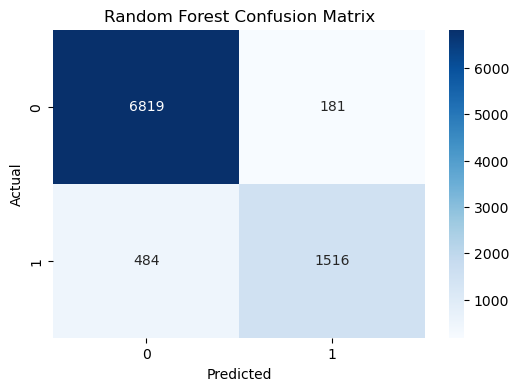

In [ ]:
# Visualize the Random Forest confusion matrix for easier interpretation.

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# Compare the accuracy of Logistic Regression, KNN and Random Forest.

log_accuracy = accuracy_score(y_test, y_pred_log)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Random Forest"
    ],
    "Accuracy": [
        log_accuracy,
        knn_accuracy,
        rf_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.896778
1,KNN,0.895222
2,Random Forest,0.926111


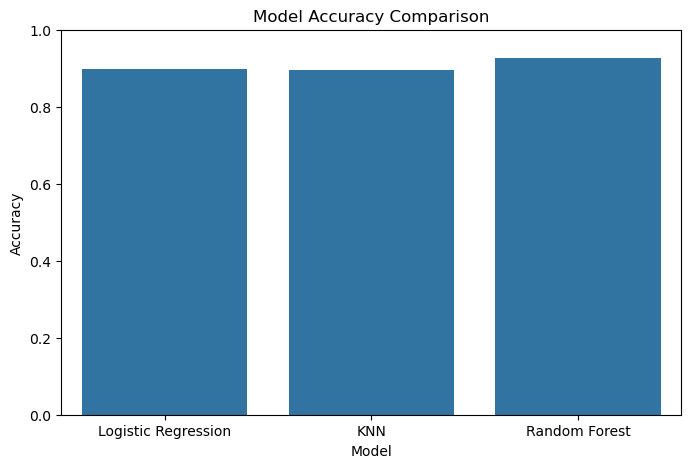

In [ ]:
# Plot the accuracy of all three machine learning models.

plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)

plt.show()

In [ ]:
# Select Random Forest as the final model because it achieved the highest accuracy among the tested models.

final_model = rf

print("Final model selected: Random Forest")
print("Final accuracy:", rf_accuracy)

Final model selected: Random Forest
Final accuracy: 0.9261111111111111


In [ ]:
# Calculate the importance of each feature in the Random Forest model.

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
12,previous_loan_defaults_on_file,0.343467
8,loan_int_rate,0.148594
9,loan_percent_income,0.123847
3,person_income,0.111607
5,person_home_ownership,0.050661
6,loan_amnt,0.049616
11,credit_score,0.047036
7,loan_intent,0.031310
0,person_age,0.026148
4,person_emp_exp,0.024042


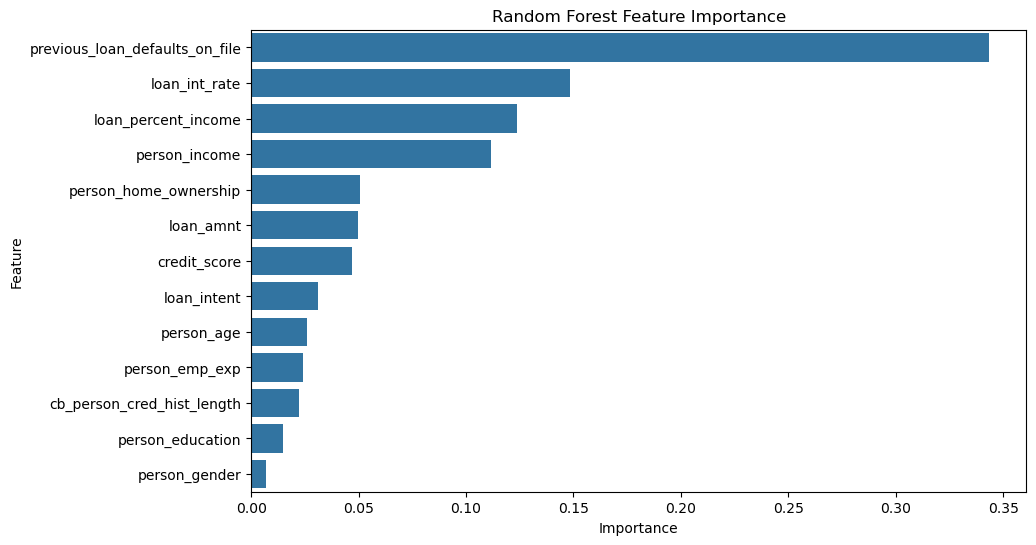

In [ ]:
# Visualize which features contributed most to the Random Forest predictions.

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

In [ ]:
# Select one real approved loan from the original dataset for a final model test.

approved_raw = data[data["loan_status"] == 1].iloc[[0]].copy()

print(approved_raw)

   person_age person_gender person_education  person_income  person_emp_exp  \
0        22.0        female           Master        71948.0               0   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.49                         3.0           561   

  previous_loan_defaults_on_file  loan_status  
0                             No            1  


In [ ]:
# Apply the same saved LabelEncoders to the approved record before sending it to the model.

approved_test = approved_raw.drop("loan_status", axis=1).copy()

for col in categorical_cols:
    approved_test[col] = encoders[col].transform(
        approved_test[col]
    )

print("Encoded approved test record:")
print(approved_test)

Encoded approved test record:
   person_age  person_gender  person_education  person_income  person_emp_exp  \
0        22.0              0                 4        71948.0               0   

   person_home_ownership  loan_amnt  loan_intent  loan_int_rate  \
0                      3    35000.0            4          16.02   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.49                         3.0           561   

   previous_loan_defaults_on_file  
0                               0  


In [ ]:
# Check whether Random Forest correctly predicts the real approved loan.

prediction = rf.predict(approved_test)[0]

print("Actual Status:", 1)
print("Model Prediction:", prediction)

Actual Status: 1
Model Prediction: 1


In [ ]:
# Display the model's rejection and approval probabilities for the test record.

probability = rf.predict_proba(approved_test)[0]

print("Prediction Probability:", probability)
print(f"Approval Probability: {probability[1] * 100:.2f}%")

Prediction Probability: [0.07 0.93]
Approval Probability: 93.00%


In [ ]:
# Save the trained Random Forest model so Streamlit can use it without retraining.

joblib.dump(
    final_model,
    "random_forest_model.pkl"
)

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


In [ ]:
# Save the categorical encoders so Streamlit converts user inputs exactly like the training data.

joblib.dump(
    encoders,
    "encoders.pkl"
)

print("Encoders saved successfully.")

Encoders saved successfully.


In [ ]:
# Verify that the trained model and encoders can be loaded successfully.

loaded_model = joblib.load("random_forest_model.pkl")
loaded_encoders = joblib.load("encoders.pkl")

print("Model loaded:", type(loaded_model))
print("Encoders loaded:", list(loaded_encoders.keys()))

Model loaded: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Encoders loaded: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']


In [ ]:
# Confirm that the saved model produces the same prediction as the original Random Forest model.

saved_prediction = loaded_model.predict(
    approved_test
)[0]

saved_probability = loaded_model.predict_proba(
    approved_test
)[0]

print("Saved Model Prediction:", saved_prediction)
print("Saved Model Probability:", saved_probability)

Saved Model Prediction: 1
Saved Model Probability: [0.07 0.93]


In [ ]:
# Display the final project performance summary.

print("=" * 50)
print("LOAN APPROVAL PREDICTION PROJECT")
print("=" * 50)

print(f"Logistic Regression Accuracy : {log_accuracy * 100:.2f}%")
print(f"KNN Accuracy                : {knn_accuracy * 100:.2f}%")
print(f"Random Forest Accuracy      : {rf_accuracy * 100:.2f}%")

print("=" * 50)
print("Final Model: Random Forest")
print("=" * 50)

LOAN APPROVAL PREDICTION PROJECT
Logistic Regression Accuracy : 89.68%
KNN Accuracy                : 89.52%
Random Forest Accuracy      : 92.61%
Final Model: Random Forest
